In [1]:
# calibrating prompt 7

# "If a candidate represents the 'Frontline' or 'Craft' version of the role (e.g., Waiter, Electrician, Technician), it MUST be preferred over the 'Managerial' version (Manager, Engineer) unless the job tasks explicitly describe managing people or high-level system design."
# Rumando ao fim update a partir do prompt 6

#Default pipeline: E5 + Llama, with union (E5 top5 + BGE top5 → ≤10) only for uncertain jobs.

#Prompt rule: return 2–3 by default; return only 1 if very sure; never 0 or >3.

#Hard gates: JSON ≥99.5%, empty ≤0.5%, max kept ≤3, avg kept ≤2.2, latency ≤1.2×.

#Quality + fallback triggers: IT leakage ≤5%, hierarchy ≤0.5%, anchor ≤1%, low margin ≤25%; fallback ≤10–15%.

#Next steps: lock prompt + thresholds, run 50k stratified validation, then launch 20M run with audit logging.

# Helpers

In [2]:
import json
import re
import random
import statistics
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
_RUN_RE = re.compile(
    r"llama_drop_only_(?P<month>adzuna_month\d{2})_(?P<start>\d+)_(?P<stop>\d+)_job(?P<jobid>\d+)_task(?P<taskid>\d+)_\d{8}_\d{6}\.jsonl$"
)

IT_PATTERNS = [
    r"\bsoftware\b", r"\bdeveloper\b", r"\bengineer\b", r"\bdata\b", r"\bml\b", r"\bai\b",
    r"\bcloud\b", r"\bcyber\b", r"\bsecurity\b", r"\bnetwork\b", r"\bsystems?\b",
    r"\bdatabase\b", r"\bit\b", r"\bdevops\b"
]
_IT_RE = re.compile("|".join(IT_PATTERNS), flags=re.I)

def _is_it_role(title: str) -> bool:
    if not title:
        return False
    return bool(_IT_RE.search(title))


def _infer_npz_from_jsonl(jsonl_path: Path) -> Path:
    """
    NEW layout:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>/llama_drop_only_....jsonl
    NPZ sits at:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>.npz
    """
    m = _RUN_RE.search(jsonl_path.name)
    if not m:
        raise ValueError(f"JSONL filename doesn't match expected pattern: {jsonl_path.name}")

    month = m.group("month")
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    return embed_root / f"{month}.npz"


def _get_job_ids(z) -> np.ndarray:
    """
    Supports both schemas:
      new: job_ids
      old: job_id
    Returns np.ndarray[str]
    """
    if "job_ids" in z.files:
        return z["job_ids"].astype(str)
    if "job_id" in z.files:
        return z["job_id"].astype(str)
    raise KeyError(f"NPZ missing job id key. Need job_ids or job_id. Have={sorted(z.files)}")


def _load_npz_lookup(npz_path: Path):
    """
    Expects stage3-prep NPZ keys (canonical):
      job_ids (or job_id), job_ad_title, job_desc, job_tasks, domain, job_sector_category, job_description
    """
    with np.load(npz_path, allow_pickle=True) as z:
        job_ids = _get_job_ids(z)

        # canonical (your stage3-prep)
        job_ad_title = z["job_ad_title"]
        job_desc = z["job_desc"]
        job_tasks = z["job_tasks"]

        domain = z["domain"] if "domain" in z.files else None
        job_sector_category = z["job_sector_category"] if "job_sector_category" in z.files else None
        job_description = z["job_description"] if "job_description" in z.files else None

    lookup = {}
    for i, jid in enumerate(job_ids):
        lookup[jid] = {
            "job_ad_title": None if job_ad_title[i] is None else str(job_ad_title[i]),
            "job_desc": None if job_desc[i] is None else str(job_desc[i]),
            "job_tasks": None if job_tasks[i] is None else str(job_tasks[i]),
            "job_description": None if job_description is None or job_description[i] is None else str(job_description[i]),
            "domain": None if domain is None or domain[i] is None else str(domain[i]),
            "job_sector_category": None if job_sector_category is None or job_sector_category[i] is None else str(job_sector_category[i]),
        }
    return lookup


# ---------------------------------------------------------------------
# Main: report generator
# ---------------------------------------------------------------------
def gen_report(jsonl_path: str, *, npz_path: str | None = None, sample_n: int = 30, seed: int = 0):
    """
    jsonl_path: path to llama_drop_only_*.jsonl
    npz_path  : optional explicit context NPZ. If None, inferred from jsonl name/dir.
    """
    random.seed(seed)

    jsonl_path = Path(jsonl_path)
    if not jsonl_path.exists():
        raise FileNotFoundError(f"Missing JSONL: {jsonl_path}")

    inferred_npz = _infer_npz_from_jsonl(jsonl_path)
    npz_path = Path(npz_path) if npz_path else inferred_npz
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing NPZ: {npz_path}")

    # report folder: put it under .../llm_negative_selection/<EMBED>/evaluation_reports/
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    report_dir = embed_root / "evaluation_reports"
    report_dir.mkdir(parents=True, exist_ok=True)

    print("JSONL:", jsonl_path)
    print("NPZ :", npz_path)
    print("OUT :", report_dir)

    lookup = _load_npz_lookup(npz_path)

    before_counts = []
    after_counts = []
    kept_titles = Counter()
    domain_kept = defaultdict(list)

    it_leak = 0
    total_kept = 0
    empty_outputs = 0

    samples = []
    seen_sample_ids = set()

    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                r = json.loads(line)
            except Exception:
                continue

            jid = str(r.get("job_id", "")).strip()
            if not jid:
                continue

            ctx = lookup.get(jid, {})

            cand = r.get("candidates") or []
            final = r.get("final") or []

            before_counts.append(len(cand))
            after_counts.append(len(final))

            if len(final) == 0:
                empty_outputs += 1

            for t in final:
                kept_titles[t] += 1
                total_kept += 1
                if _is_it_role(t):
                    it_leak += 1

            dom = ctx.get("domain") or "UNKNOWN"
            domain_kept[dom].append(len(final))

            # sample gate
            if len(samples) < sample_n and jid not in seen_sample_ids and random.random() < 0.05:
                seen_sample_ids.add(jid)
                samples.append({
                    "job_id": jid,
                    "job_ad_title": ctx.get("job_ad_title"),
                    "domain": ctx.get("domain"),
                    "sector": ctx.get("job_sector_category"),
                    "job_desc": ctx.get("job_desc"),
                    "kept": final,
                    "dropped": r.get("drop") or [],
                })

    if not before_counts:
        raise RuntimeError("No valid rows parsed from JSONL.")

    before_avg = statistics.mean(before_counts)
    after_avg = statistics.mean(after_counts)
    drop_rate = 1.0 - (after_avg / before_avg if before_avg else 0.0)
    it_share = it_leak / max(total_kept, 1)

    metrics = {
        "jobs": len(before_counts),
        "avg_candidates_before": round(before_avg, 3),
        "avg_candidates_after": round(after_avg, 3),
        "drop_rate": round(drop_rate, 4),
        "empty_outputs_percent": round(100.0 * empty_outputs / len(before_counts), 3),
        "it_leakage_share": round(it_share, 4),
        "min_kept": int(min(after_counts)),
        "max_kept": int(max(after_counts)),
    }

    domain_summary = {d: round(statistics.mean(v), 3) for d, v in domain_kept.items()}

    report = {
        "run": {
            "jsonl": str(jsonl_path),
            "npz": str(npz_path),
            "generated_at": datetime.now().isoformat(timespec="seconds"),
        },
        "global_metrics": metrics,
        "top_kept_roles": kept_titles.most_common(25),
        "domain_summary_avg_kept": dict(sorted(domain_summary.items(), key=lambda x: (-x[1], x[0]))),
        "sample_cases": samples,
    }

    base = jsonl_path.stem
    report_json = report_dir / f"{base}_report.json"
    report_txt = report_dir / f"{base}_report.txt"

    with report_json.open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    with report_txt.open("w", encoding="utf-8") as f:
        f.write("=== GLOBAL METRICS ===\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")

        f.write("\n=== TOP KEPT OCCUPATIONS ===\n")
        for title, cnt in kept_titles.most_common(25):
            f.write(f"{cnt}  {title}\n")

        f.write("\n=== DOMAIN AVG KEPT ===\n")
        for d, v in sorted(domain_summary.items(), key=lambda x: (-x[1], x[0])):
            f.write(f"{d}: {v}\n")

        f.write("\n=== SAMPLE CASES (truncated) ===\n")
        for s in samples[:10]:
            f.write(f"\njob_id: {s['job_id']}\n")
            f.write(f"title:  {s.get('job_ad_title')}\n")
            f.write(f"domain: {s.get('domain')} | sector: {s.get('sector')}\n")
            f.write(f"kept:   {s.get('kept')}\n")
            f.write(f"drop:   {s.get('dropped')}\n")

    print("\nSaved:")
    print(" ", report_json)
    print(" ", report_txt)

    return report_json, report_txt


# Prompt 8 - calibrating promtp 7

In [3]:
# ===== Prompt printer: AISI ECONOMIST AUDITOR (Anti-Lure & Craft Version) =====

import numpy as np
from pathlib import Path

# ---- CONFIG ----
# Update this path to your specific E5 or BGE .npz file
NPZ_PATH = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz")
ROW_IDX = 35  # Sample row to print for verification


# ---- LOAD ----
data = np.load(NPZ_PATH, allow_pickle=True)

# Map NPZ keys to prompt variables
job_ad_title = str(data["job_ad_title"][ROW_IDX])
domain = str(data["domain"][ROW_IDX])
job_sector_category = str(data["job_sector_category"][ROW_IDX])
job_desc = str(data["job_desc"][ROW_IDX])
job_tasks = data["job_tasks"][ROW_IDX]
job_full_ads = data["job_description"][ROW_IDX]
row_candidates = data["titles"][ROW_IDX]

# Prepare variables for prompt logic
tasks_str = ", ".join([str(t).strip() for t in job_tasks if t]) if isinstance(job_tasks, (list, np.ndarray)) else str(job_tasks)
numbered = "\n".join([f"{i+1}. {t}" for i, t in enumerate(row_candidates) if t])
full_excerpt = str(job_full_ads).strip()[:700] if job_full_ads else ""
full_block = (
    f"\nFULL AD EXCERPT (use for concrete tools/duties only):\n{full_excerpt}\n"
    if full_excerpt else ""
)

# ---- BUILD PROMPT ----

prompt = f"""
TASK
You are a Senior Labor Market Economist. Evaluate candidate occupations and DROP those that are NOT functional matches for the job.

GOAL
- Default: keep 2–3 best matches if they represent valid aspects of the role.
- Selectivity: return exactly 1 ONLY if you are extremely sure it is the only correct match.
- Constraint: Never return 0 candidates. Never return more than 3.

JOB CONTEXT (SOURCE OF TRUTH)
Title: {job_ad_title}
Sector/Domain: {job_sector_category} | {domain}

CORE EVIDENCE (Functional Truth)
Tasks/Skills: {tasks_str}

Secondary (Context)
Short Desc: {job_desc}
{full_block}

CANDIDATES (1-based)
{numbered}

ANCHOR PROTECTION
1) The ANCHOR is the candidate whose FUNCTION most directly matches the job title’s primary role (not seniority, not specialization).
2) NEVER drop the ANCHOR unless CORE EVIDENCE explicitly contradicts that function.
3) If the title contains a clear core keyword (e.g., software, nurse, electrician, driver, interviewer), you MUST favor the candidate containing the same functional keyword or its standard occupational equivalent.
4) Do NOT replace a general functional match with a niche or senior specialty (e.g., Robotics Engineer, Research Specialist) unless CORE EVIDENCE clearly describes that specialty.

HIERARCHY & IT GATES
1) MANAGER SUPPRESSION
   - If the title does NOT include "Manager", "Lead", "Head", "Director", "Supervisor", or "Foreman",
     DROP managerial candidates in favor of frontline or operational roles,
     unless CORE EVIDENCE explicitly describes leadership, budgeting, or staff management duties.

2) IT DOMAIN LOCK
   - If the Sector/Domain is NOT IT-related,
     DROP "Software Developer", "IT Project Manager", or similar IT occupations
     unless CORE EVIDENCE explicitly mentions building or coding software
     (e.g., Python, Java, SQL, APIs, Git, React, Android, iOS).
   - Simple tool usage (Excel, SAP, internal apps) is NOT IT work.

3) CRAFT PREFERENCE
   - Prefer "Technician", "Mechanic", "Operator", or "Installer" over "Engineer" or "Manager"
     when tasks are hands-on, practical, or site-based.

ANTI-LURE SAFETY CHECKS
- Interviewer vs Sales: If title/tasks indicate surveys, research, or questionnaires,
  DROP "Telemarketers" unless sales, quotas, or commissions are explicitly mentioned.
- Driving roles: If title indicates HGV/LGV/Class 1/Class 2 driving,
  prefer long-haul or goods vehicle drivers over warehouse or forklift operators,
  unless CORE EVIDENCE is primarily warehouse-based.

PRUNING RULES
1) Specificity: Keep both a generic parent and a relevant specialist ONLY if both are clearly supported by the tasks.
2) If more than 3 candidates remain valid, drop the most generic or least title-aligned ones first.
3) Managerial and administrative roles should be dropped before functional matches.

RE-ANCHOR (Final Check)
Title: {job_ad_title}
Primary Tasks: {tasks_str}
Sector/Domain: {job_sector_category} | {domain}

OUTPUT
Return ONLY valid JSON. No text. No explanation.
Schema:
{{"drop":[...]}}
""".strip()

# ---- PRINT ----
print("-" * 60)
print(f"VERIFIED PRODUCTION PROMPT (ROW {ROW_IDX}):")
print("-" * 60)
print(prompt)
print("-" * 60)

------------------------------------------------------------
VERIFIED PRODUCTION PROMPT (ROW 35):
------------------------------------------------------------
TASK
You are a Senior Labor Market Economist. Evaluate candidate occupations and DROP those that are NOT functional matches for the job.

GOAL
- Default: keep 2–3 best matches if they represent valid aspects of the role.
- Selectivity: return exactly 1 ONLY if you are extremely sure it is the only correct match.
- Constraint: Never return 0 candidates. Never return more than 3.

JOB CONTEXT (SOURCE OF TRUTH)
Title: Sommelier-Restaurant Gordon Ramsay
Sector/Domain: Hospitality & Catering Jobs | Hospitality & Catering

CORE EVIDENCE (Functional Truth)
Tasks/Skills: [Hospitality & Catering] Assist the Head Sommelier with wine and beverage service Supervise setting up and clearing down after each service Recommend and sell wines to guests Engage with customers to deliver high levels of service Supervise wine and beverage service WSET

## bge

In [4]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_bge.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
bge_jobid = jobid

JOBID: 2186692


## e5

In [5]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_e5.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
e5_jobid = jobid

JOBID: 2186693


## gte

In [6]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_gte.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
gte_jobid = jobid

JOBID: 2186694


In [7]:
# monitoring

In [8]:
import time, subprocess
from pathlib import Path

LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout.strip()
while True:
    print("\n=== squeue ===")
    sq = sh(f"squeue -j {jobid}")
    print(sq if sq else "<finished>")

    out_logs = sorted(LOG_DIR.glob(f"*{jobid}*.out"))
    err_logs = sorted(LOG_DIR.glob(f"*{jobid}*.err"))

    if out_logs:
        print("\n--- STDOUT ---")
        print(sh(f"tail -n 20 {out_logs[-1]}"))

    if err_logs:
        print("\n--- STDERR ---")
        print(sh(f"tail -n 20 {err_logs[-1]}"))

    if not sq:
        break

    time.sleep(5)



=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2186694 autonomyluiz     workq z_llama_drop_new_test_gt PD    6:00:00       0:00    6:00:00     1 (None)

=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2186694 autonomyluiz     workq z_llama_drop_new_test_gt  R    6:00:00       0:04    5:59:56     1 nid010218

--- STDOUT ---
PROJECT=/projects/a5u/adu_dev/aisi-economy-index
BASE=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev
SCRIPT=/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drops_fix_test.py
NPZ_DIR=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large
total 7,0M
drwxr-xr-x 2 autonomyluiz.a5u autonomyluiz.a5u 4,0K fev  6 16:08 adzuna_month01
-rw-r--r-- 1 autonomylu

In [9]:
import time, subprocess
from pathlib import Path

for jobid in [bge_jobid, e5_jobid, gte_jobid]:
    LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
    
    DONE_TAG = "DONE] wrote:"
    
    def sh(cmd: str) -> str:
        return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout
    
    def tail(path: Path, n: int = 80) -> str:
        return sh(f"tail -n {n} {path}")
    
    def latest_log(jobid: int, suffix: str) -> Path | None:
        logs = sorted(LOG_DIR.glob(f"*{jobid}*{suffix}"))
        return logs[-1] if logs else None
    
    seen = set()
    
    import time
    
    done_path = None
    
    while True:
        out_log = latest_log(jobid, ".out")
    
        if out_log and out_log.exists():
            chunk = tail(out_log, 120)
            for line in chunk.splitlines():
                if DONE_TAG in line:
                    done_path = line.split(DONE_TAG, 1)[1].strip()
                    print(f"[DONE] {done_path}")
                    break
    
            if done_path:
                break
    
        time.sleep(5)
    
    
    done_path
    print('**'*50)



[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640.jsonl
****************************************************************************************************
[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186693_task0_20260206_163642.jsonl
****************************************************************************************************
[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186694_task0_20260206_163642.jsonl
****************************************************************************************************


## Results comparison


--- BGE ---
JSONL: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640.jsonl
NPZ : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz
OUT : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports

Saved:
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640_report.json
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640_report.txt

--- E5 ---
JSONL:

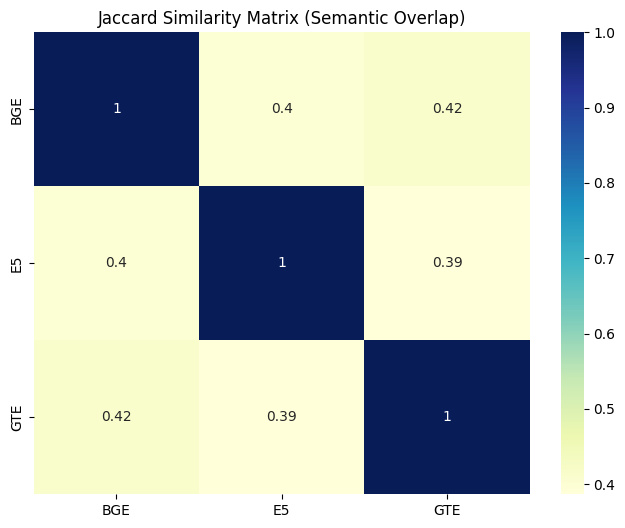

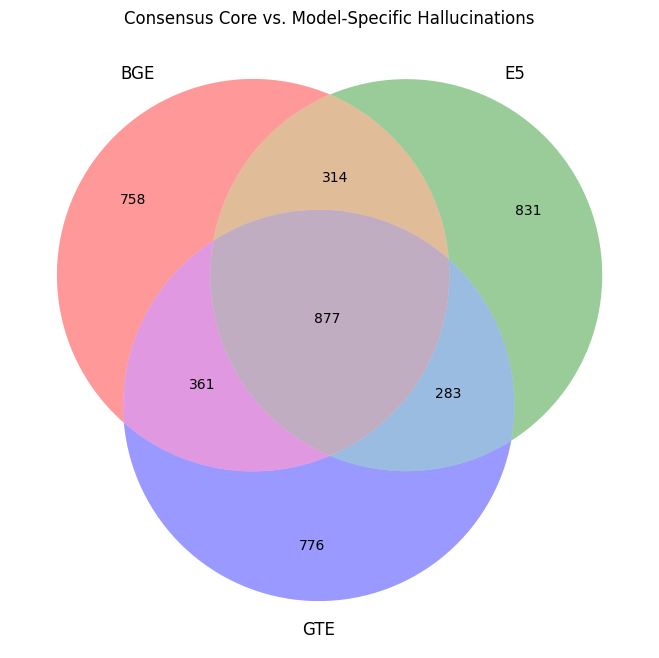

In [19]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from pathlib import Path

# ---- CONFIG ----
BASE_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection")

# 1. Define once (Update these only)
PATHS = {
    "BGE": BASE_DIR / "bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640.jsonl",
    "E5":  BASE_DIR / "e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186693_task0_20260206_163642.jsonl",
    "GTE": BASE_DIR / "gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186694_task0_20260206_163642.jsonl"
}

# 2. Run reports automatically for each
for model_name, file_path in PATHS.items():
    print(f"\n--- {model_name} ---")
    if file_path.exists():
        gen_report(str(file_path))
    else:
        print(f"Error: File for {model_name} not found at {file_path}")
def load_data(filepath):
    data = {}
    if not filepath.exists(): return data
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            data[obj['job_id']] = set(obj['final'])
    return data

# 1. Load and Intersect
results = {name: load_data(path) for name, path in PATHS.items()}
loaded = [n for n, d in results.items() if d]
common_ids = set.intersection(*[set(results[m].keys()) for m in loaded])

# 2. Extract Commonalities and Differences
report_data = []
for jid in common_ids:
    bge_set = results["BGE"].get(jid, set())
    e5_set = results["E5"].get(jid, set())
    gte_set = results["GTE"].get(jid, set())
    
    # Are they identical?
    all_agree = (bge_set == e5_set == gte_set)
    
    # Who is the outlier?
    outlier = "None"
    if bge_set == e5_set != gte_set: outlier = "GTE"
    elif bge_set == gte_set != e5_set: outlier = "E5"
    elif e5_set == gte_set != bge_set: outlier = "BGE"
    elif not all_agree: outlier = "All Diverged"

    report_data.append({
        "job_id": jid,
        "all_agree": all_agree,
        "outlier": outlier,
        "bge_count": len(bge_set),
        "e5_count": len(e5_set),
        "gte_count": len(gte_set),
        "consensus_count": len(bge_set & e5_set & gte_set)
    })

df = pd.DataFrame(report_data)

# 3. Print Statistical Summary
print("=== COMPREHENSIVE COMPARISON REPORT ===")
print(f"Total Common Jobs: {len(df)}")
print(f"Absolute Consensus: {df['all_agree'].sum()} ({df['all_agree'].mean():.1%})")
print("\n--- Outlier Frequency (Who disagrees with the majority?) ---")
print(df[df['outlier'] != "None"]['outlier'].value_counts())

# 4. Generate Visualizations
# Jaccard Heatmap
model_names = list(results.keys())
j_matrix = np.zeros((3, 3))
for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        scores = [len(results[m1][jid] & results[m2][jid]) / len(results[m1][jid] | results[m2][jid]) 
                  for jid in common_ids]
        j_matrix[i, j] = np.mean(scores)

plt.figure(figsize=(8, 6))
sns.heatmap(j_matrix, annot=True, xticklabels=model_names, yticklabels=model_names, cmap="YlGnBu")
plt.title("Jaccard Similarity Matrix (Semantic Overlap)")
plt.savefig("semantic_overlap_heatmap.png")

# Venn Diagram
venn_sets = []
for name in model_names:
    s = set()
    for jid in common_ids:
        for occ in results[name][jid]:
            s.add(f"{jid}|{occ}")
    venn_sets.append(s)

plt.figure(figsize=(10, 8))
venn3(venn_sets, set_labels=model_names)
plt.title("Consensus Core vs. Model-Specific Hallucinations")
plt.savefig("assignment_venn.png")

In [17]:
from pathlib import Path

# 1. Define your specific report files once
REPORTS = {
    "BGE_LARGE": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640_report.txt",
    "E5_LARGE":  "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2186693_task0_20260206_163642_report.txt",
    "GTE_LARGE": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2186694_task0_20260206_163642_report.txt"
}
# 1. Define once (Update these only)


# 2. Loop through and print with clear headers
for model_name, file_path in REPORTS.items():
    p = Path(file_path)
    
    # Visual Header for scannability
    print("\n" + "="*60)
    print(f"****** {model_name} ******")
    print("="*60)
    
    if p.exists():
        print(p.read_text())
    else:
        print(f"FILE NOT FOUND: {file_path}")


****** BGE_LARGE ******
=== GLOBAL METRICS ===
jobs: 1000
avg_candidates_before: 8.221
avg_candidates_after: 2.31
drop_rate: 0.719
empty_outputs_percent: 0.0
it_leakage_share: 0.0714
min_kept: 1
max_kept: 3

=== TOP KEPT OCCUPATIONS ===
45  Information Technology Project Managers
38  Personal Care Aides
35  Sales Managers
34  Software Developers
33  Customer Service Representatives
28  Financial Managers
24  Home Health Aides
24  Computer Systems Engineers/Architects
22  Nursing Assistants
21  Mental Health and Substance Abuse Social Workers
20  Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products
20  First-Line Supervisors of Retail Sales Workers
19  Social and Human Service Assistants
19  Chefs and Head Cooks
19  Marketing Managers
18  Acute Care Nurses
18  Accountants and Auditors
18  Registered Nurses
18  Architectural and Engineering Managers
18  Bookkeeping, Accounting, and Auditing Clerks
17  Healthcare Social Workers
17  Advertising and Promoti

In [12]:
PATHS = {
    "BGE": BASE_DIR / "bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640.jsonl",
    "E5":  BASE_DIR / "e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186693_task0_20260206_163642.jsonl",
    "GTE": BASE_DIR / "gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186694_task0_20260206_163642.jsonl"
}


notebook_name ='08_prompt'

In [18]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# 1. EXACT CONFIGURATION
PATHS = {
    "BGE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186692_task0_20260206_163640.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz",
    },
    "E5": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186693_task0_20260206_163642.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz",
    },
    "GTE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2186694_task0_20260206_163642.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01.npz",
    },
}

# 2. HELPER FUNCTIONS
def _to_str_array(x: np.ndarray) -> np.ndarray:
    if x.dtype == object:
        return np.array([v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v) for v in x])
    if np.issubdtype(x.dtype, np.bytes_):
        return np.array([v.decode("utf-8") for v in x])
    return x.astype(str)

def load_meta_from_npz(npz_path: str) -> pd.DataFrame:
    with np.load(npz_path, allow_pickle=True) as npz:
        job_id_key = "job_id" if "job_id" in npz.files else ("job_ids" if "job_ids" in npz.files else None)
        title_key = "job_ad_title" if "job_ad_title" in npz.files else ("title" if "title" in npz.files else None)
        domain_key = "domain" if "domain" in npz.files else None
        sector_key = "job_sector_category" if "job_sector_category" in npz.files else None

        meta = {
            "job_id": _to_str_array(npz[job_id_key]),
            "title": _to_str_array(npz[title_key]),
        }
        meta["domain"] = _to_str_array(npz[domain_key]) if domain_key else ""
        meta["sector"] = _to_str_array(npz[sector_key]) if sector_key else ""
    return pd.DataFrame(meta)

def load_results_from_jsonl(jsonl_path: str) -> pd.DataFrame:
    rows = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: rows.append(json.loads(line))
            except: continue

    df = pd.DataFrame(rows)
    df["job_id"] = df["job_id"].astype(str)

    if "final" in df.columns: df = df.rename(columns={"final": "kept"})
    if "drop" in df.columns: df = df.rename(columns={"drop": "dropped"})
    
    if "kept" not in df.columns: df["kept"] = None
    if "dropped" not in df.columns: df["dropped"] = None

    def _list_to_csv(x):
        if isinstance(x, list): return ", ".join(map(str, x))
        return "" if x is None else str(x)

    df["kept"] = df["kept"].apply(_list_to_csv)
    df["dropped"] = df["dropped"].apply(_list_to_csv)
    return df[["job_id", "kept", "dropped"]]

# 3. CORE BUILDER
def build_audit_dataset(paths_by_model: dict, n_jobs_per_model: int = 100, seed: int = 42) -> pd.DataFrame:
    all_frames = []
    for model, p in paths_by_model.items():
        print(f"Lendo dados para {model}...")
        meta = load_meta_from_npz(p["npz"])
        res = load_results_from_jsonl(p["jsonl"])
        
        merged = res.merge(meta, on="job_id", how="inner")
        if merged.empty:
            print(f"!!! [AVISO] {model} resultou em merge vazio.")
            continue
            
        sample_size = min(n_jobs_per_model, len(merged))
        sampled = merged.sample(n=sample_size, random_state=seed).copy()
        sampled["model"] = model
        all_frames.append(sampled)

    out = pd.concat(all_frames, ignore_index=True)
    cols = ["job_id", "model", "title", "domain", "sector", "kept", "dropped"]
    for c in cols:
        if c not in out.columns: out[c] = ""
            
    return out[cols].sort_values(["model", "job_id"]).reset_index(drop=True)

# 4. EXECUTION
if __name__ == "__main__":
    # Dinamicamente tenta pegar o nome do arquivo/notebook
    try:
        # Se for um script .py
        prefix = Path(__file__).stem
    except NameError:
        # Fallback para Jupyter Notebook (ajuste manualmente se preferir)
        prefix = notebook_name

    # Gera o dataset
    audit_df = build_audit_dataset(PATHS, n_jobs_per_model=100, seed=42)
    
    # Define o nome do arquivo com o prefixo
    out_filename = f"{prefix}_sanity_check_300_jobs_FINAL.csv"
    out_path = Path(out_filename)
    
    # Salva o CSV
    audit_df.to_csv(out_path, index=False)
    
    print("-" * 30)
    print(f"[SUCESSO] Arquivo escrito: {out_path}")
    print(f"Total de linhas: {len(audit_df)}")
    print(f"Distribuição por modelo:\n{audit_df['model'].value_counts()}")
    print("-" * 30)

Lendo dados para BGE...
Lendo dados para E5...
Lendo dados para GTE...
------------------------------
[SUCESSO] Arquivo escrito: 08_prompt_sanity_check_300_jobs_FINAL.csv
Total de linhas: 300
Distribuição por modelo:
model
BGE    100
E5     100
GTE    100
Name: count, dtype: int64
------------------------------


In [14]:
import pandas as pd
import re
import ast

# =============================================================================
# Load
# =============================================================================
file_path = "08_prompt_sanity_check_300_jobs_FINAL.csv"
df = pd.read_csv(file_path)

# Normalise model names so pivot columns are predictable
df["model"] = df["model"].astype(str).str.strip().str.lower()

# =============================================================================
# Robust parser for `kept` (handles: "['a','b']" AND "a, b")
# =============================================================================
def parse_kept(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    # Case 1: Python list literal
    if s.startswith("[") and s.endswith("]"):
        try:
            out = ast.literal_eval(s)
            if isinstance(out, list):
                return [str(i).strip() for i in out if str(i).strip()]
        except Exception:
            pass

    # Case 2: plain comma-separated
    items = re.split(r",\s*(?=[A-Z0-9])", s)
    return [i.strip().strip("[]'\"") for i in items if i.strip()]

df["kept_list"] = df["kept"].apply(parse_kept)

# =============================================================================
# Pivot: one row per job, one column per model
# =============================================================================
pivot = df.pivot_table(
    index=["job_id", "title", "domain", "sector"],
    columns="model",
    values="kept_list",
    aggfunc="first"
).reset_index()

need_models = ['bge', 'e5', 'gte']
missing_cols = [c for c in need_models if c not in pivot.columns]
if missing_cols:
    raise ValueError(
        f"Missing model columns in pivot: {missing_cols}. "
        f"Available: {sorted([c for c in pivot.columns if c not in ['job_id','title','domain','sector']])}"
    )

pivot = pivot.dropna(subset=need_models)

# =============================================================================
# Helpers
# =============================================================================
def top1(lst):
    return lst[0] if isinstance(lst, list) and len(lst) else None

def jaccard(a, b):
    sa = set(a) if isinstance(a, list) else set()
    sb = set(b) if isinstance(b, list) else set()
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / len(sa | sb)

# =============================================================================
# Divergence metrics
# =============================================================================
pivot["top1_bge"] = pivot["bge"].apply(top1)
pivot["top1_e5"]  = pivot["e5"].apply(top1)
pivot["top1_gte"] = pivot["gte"].apply(top1)

pivot["all_top1_same"] = (
    (pivot["top1_bge"] == pivot["top1_e5"]) &
    (pivot["top1_bge"] == pivot["top1_gte"])
)

pivot["jac_bge_e5"] = pivot.apply(lambda r: jaccard(r["bge"], r["e5"]), axis=1)
pivot["jac_bge_gte"] = pivot.apply(lambda r: jaccard(r["bge"], r["gte"]), axis=1)
pivot["jac_e5_gte"] = pivot.apply(lambda r: jaccard(r["e5"], r["gte"]), axis=1)

pivot["avg_jaccard"] = pivot[["jac_bge_e5", "jac_bge_gte", "jac_e5_gte"]].mean(axis=1)

# =============================================================================
# Most divergent jobs
# =============================================================================
divergent = pivot.sort_values(
    by=["avg_jaccard", "all_top1_same"],
    ascending=[True, True]
).head(20)

divergent[[
    "job_id",
    "title",
    "top1_bge",
    "top1_e5",
    "top1_gte",
    "avg_jaccard",
    "jac_bge_e5",
    "jac_bge_gte",
    "jac_e5_gte",
]]


model,job_id,title,top1_bge,top1_e5,top1_gte,avg_jaccard,jac_bge_e5,jac_bge_gte,jac_e5_gte
0,2192398821,Driving Instructor Trainee,Career/Technical Education Teachers,Cleaners of Vehicles and Equipment,Bus Drivers,0.0,0.0,0.0,0.0
9,2657197577,Senior Customer Insights Analyst,Business Intelligence Analysts,Market Research Analysts and Marketing Special...,Computer Systems Analysts,0.0,0.0,0.0,0.0
10,2669419357,HGV Technician,Transportation Vehicle,Mobile Heavy Equipment Mechanics,Bus and Truck Mechanics and Diesel Engine Spec...,0.0,0.0,0.0,0.0
11,2675175227,Customer Identity Access Management Senior Man...,Sales Managers,Security Managers,Computer Network Architects,0.0,0.0,0.0,0.0
12,2678422149,Dental Nurse,Registered Nurses,Dental Laboratory Technicians,Dental Hygienists,0.0,0.0,0.0,0.0
16,2716366432,Product Manager - Immediacy,Microsystems Engineers,Information Technology Project Managers,Commercial and Industrial Designers,0.0,0.0,0.0,0.0
19,2719730726,Executive Assistant to Director of Development...,Meeting,Executive Secretaries and Executive Administra...,Secretaries and Administrative Assistants,0.0,0.0,0.0,0.0
20,2719871758,ADMINISTRATION ASSISTANT,Correspondence Clerks,Customer Service Representatives,Secretaries and Administrative Assistants,0.0,0.0,0.0,0.0
21,2720079033,Purchasing Administrator,Logisticians,Procurement Clerks,Purchasing Agents,0.0,0.0,0.0,0.0
29,2744113462,Information Governance Officer - Police,Private Detectives and Investigators,Information Security Analysts,Security Managers,0.0,0.0,0.0,0.0
